## Series de Tiempo y Modelos Econométricos

In [1]:
# cargamos los datos
import pandas as pd
data = pd.read_csv('Mercado laboral y población.csv', sep=';')
# mostramos las primeras filas del dataframe
data.head()

,"Periodo(MMM, AAAA)",Tasa de desempleo - total nacional,Tasa de ocupación - total nacional
0,2001/01/31,"16,62","57,58"
1,2001/02/28,"17,43","56,93"
2,2001/03/31,"15,81","57,57"
3,2001/04/30,"14,52","55,76"
4,2001/05/31,"14,04","56,23"


In [2]:
# importamos libreria de series de tiempo
import statsmodels.api as sm


In [3]:
# las variables son
data.dtypes

Periodo(MMM, AAAA)                    str
Tasa de desempleo - total nacional    str
Tasa de ocupación - total nacional    str
dtype: object

In [4]:
# ver en blanco
data.isnull().sum()

Periodo(MMM, AAAA)                    0
Tasa de desempleo - total nacional    0
Tasa de ocupación - total nacional    0
dtype: int64

In [5]:
# tengo que cambiar el formato de las tasas de desempleo a formato numérico
data['Tasa de desempleo - total nacional'] = data['Tasa de desempleo - total nacional'].str.replace(',', '.').astype(float)
data['Tasa de ocupación - total nacional'] = data['Tasa de ocupación - total nacional'].str.replace(',', '.').astype(float)

In [6]:
# comprobamos 
data.dtypes

Periodo(MMM, AAAA)                        str
Tasa de desempleo - total nacional    float64
Tasa de ocupación - total nacional    float64
dtype: object

In [7]:
# la columna de periodo debe ser de tipo fecha
data['Periodo(MMM, AAAA)'] = pd.to_datetime(
    data['Periodo(MMM, AAAA)'],
    format='mixed',
    errors='coerce'
)
# comprobamos
data.dtypes


Periodo(MMM, AAAA)                    datetime64[us]
Tasa de desempleo - total nacional           float64
Tasa de ocupación - total nacional           float64
dtype: object

In [8]:
#rango de fechas
data['Periodo(MMM, AAAA)'].min(), data['Periodo(MMM, AAAA)'].max()

(Timestamp('2001-01-31 00:00:00'), Timestamp('2026-01-31 00:00:00'))

In [9]:
# vamos a ajustar la temporalidad de los datos 
# para que todas las fechas sean con el dia 1 del mes
data['Periodo(MMM, AAAA)'] = data['Periodo(MMM, AAAA)'].dt.to_period('M').dt.to_timestamp()
# comprobamos
data['Periodo(MMM, AAAA)'].min(), data['Periodo(MMM, AAAA)'].max()

(Timestamp('2001-01-01 00:00:00'), Timestamp('2026-01-01 00:00:00'))

In [10]:
# vemos como se ven los datos
data.head()

,"Periodo(MMM, AAAA)",Tasa de desempleo - total nacional,Tasa de ocupación - total nacional
0,2001-01-01,16.62,57.58
1,2001-02-01,17.43,56.93
2,2001-03-01,15.81,57.57
3,2001-04-01,14.52,55.76
4,2001-05-01,14.04,56.23


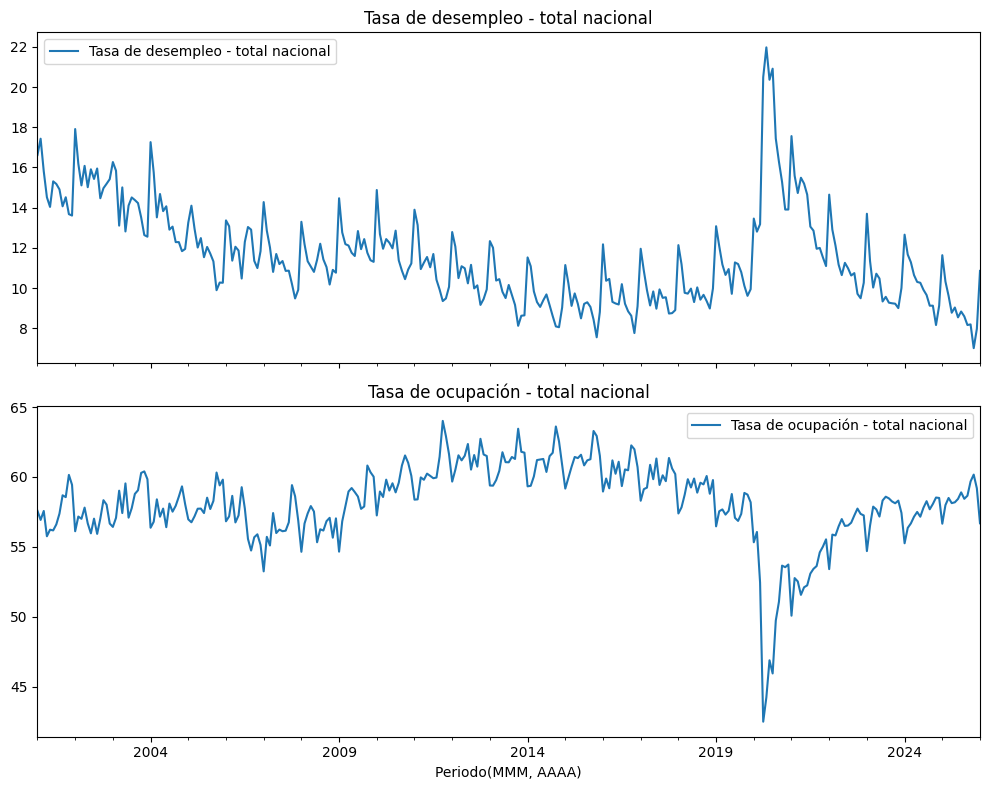

In [11]:
# veamos ambas series en dos graficas separadas en un grid 2x1
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
data.plot(x='Periodo(MMM, AAAA)', y='Tasa de desempleo - total nacional', ax=axes[0], title='Tasa de desempleo - total nacional')
data.plot(x='Periodo(MMM, AAAA)', y='Tasa de ocupación - total nacional', ax=axes[1], title='Tasa de ocupación - total nacional')
plt.tight_layout()
plt.show()

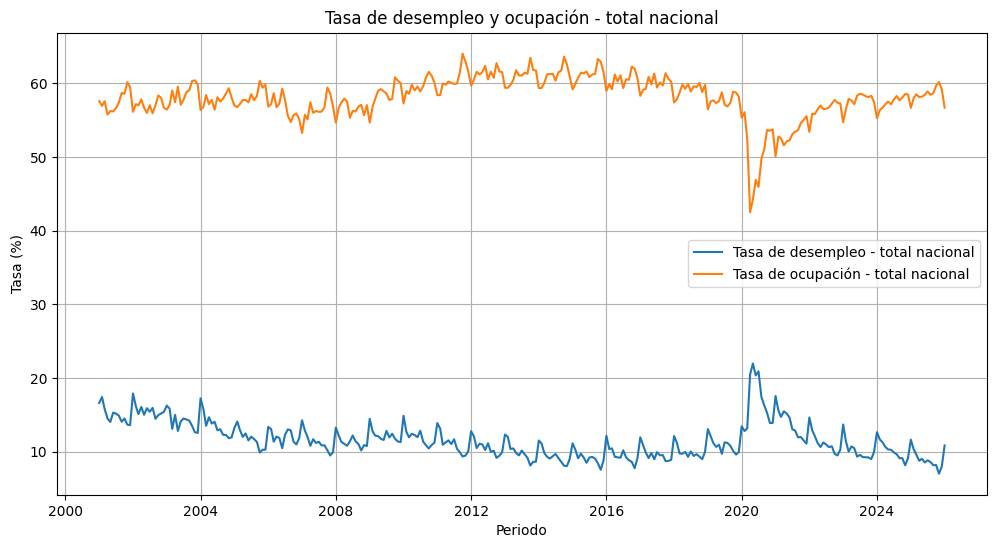

In [12]:
# ahora si grafiquemos las tasas de desempleo y ocupación
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(data['Periodo(MMM, AAAA)'], data['Tasa de desempleo - total nacional'], label='Tasa de desempleo - total nacional')
plt.plot(data['Periodo(MMM, AAAA)'], data['Tasa de ocupación - total nacional'], label='Tasa de ocupación - total nacional')
plt.xlabel('Periodo')
plt.ylabel('Tasa (%)')
plt.title('Tasa de desempleo y ocupación - total nacional')
plt.legend()
plt.grid()
plt.show()

### Pasos para las series de tiempo

1. Graficar y enteneder la serie de tiempo. Tiene tendencia? Tiene estacionalidad? Es estacionaria?
2. Descomponer la serie de tiempo en sus componentes: tendencia, estacionalidad y residuo.
3. Aplicar transformaciones si es necesario (logaritmo, diferencia, etc.) para estabilizar la varianza y hacer la serie estacionaria.
4. Estimar modelos de series de tiempo (ARIMA, SARIMA, etc.) y evaluar su desempeño entre si para seleccionar el mejor modelo.
5. Validar el modelo seleccionado utilizando técnicas de validación cruzada o dividiendo los datos en conjuntos de entrenamiento y prueba.
6. Realizar pronósticos utilizando el modelo seleccionado y evaluar su precisión utilizando métricas como el error cuadrático medio (MSE) o el error absoluto medio (MAE).

In [13]:
# vamos a hacer una division de 80% para entrenamiento y 20% para prueba
# pero al ser un modelo de series de tiempo, no podemos hacer una division aleatoria, sino que debemos hacer una division temporal
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]
# comprobamos las formas de los datos
print(f'Tamaño del conjunto de entrenamiento: {len(train_data)}')
print(f'Tamaño del conjunto de prueba: {len(test_data)}')

Tamaño del conjunto de entrenamiento: 240
Tamaño del conjunto de prueba: 61


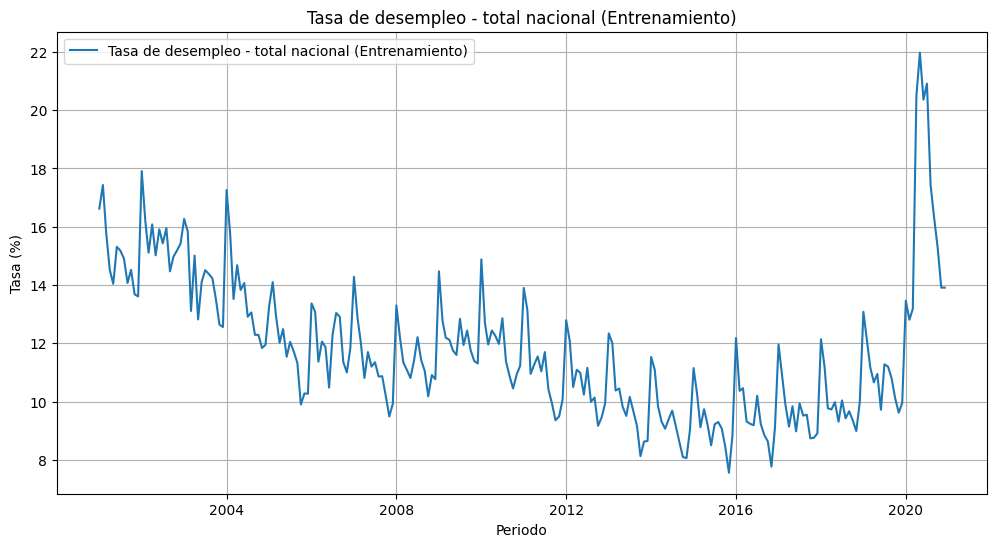

In [14]:
# graficamos la serie de tiempo de entrenamiento 
# solo haremos la grafica de la tasa de desempleo
plt.figure(figsize=(12, 6))
plt.plot(train_data['Periodo(MMM, AAAA)'], train_data['Tasa de desempleo - total nacional'], label='Tasa de desempleo - total nacional (Entrenamiento)')
plt.xlabel('Periodo')
plt.ylabel('Tasa (%)')
plt.title('Tasa de desempleo - total nacional (Entrenamiento)')
plt.legend()
plt.grid()
plt.show()

In [15]:
# entrenamos varios modelos de series de tiempo y evaluamos su desempeño entre si para seleccionar el mejor modelo
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error 
import numpy as np

# definimos una funcion para evaluar los modelos
def evaluate_model(model, test_data, column):
    predictions = model.predict(start=test_data.index[0], end=test_data.index[-1])
    mse = mean_squared_error(test_data[column], predictions)
    mae = mean_absolute_error(test_data[column], predictions)
    return mse, mae
# entrenamos un modelo ARIMA
arima_model = ARIMA(train_data['Tasa de desempleo - total nacional'], order=(1,1,1))
arima_model_fit = arima_model.fit()
arima_mse, arima_mae = evaluate_model(arima_model_fit, test_data, 'Tasa de desempleo - total nacional')
print(f'ARIMA - MSE: {arima_mse}, MAE: {arima_mae}')

ARIMA - MSE: 20.013164680963445, MAE: 4.087532633217937


In [16]:
# entrenamos un modelo SARIMA
sarima_model = SARIMAX(train_data['Tasa de desempleo - total nacional'], order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_model_fit = sarima_model.fit()
sarima_mse, sarima_mae = evaluate_model(sarima_model_fit, test_data, 'Tasa de desempleo - total nacional')
print(f'SARIMA - MSE: {sarima_mse}, MAE: {sarima_mae}')

SARIMA - MSE: 76.02486955944966, MAE: 8.021202275871156


Vamos a escoger el que tenga el MSE más bajo o el MAE más bajo como nuestro modelo final. En este caso el ARIMA tiene por mucha diferencia el mejor desempeño, por lo que lo seleccionaremos como nuestro modelo final para realizar pronósticos futuros.

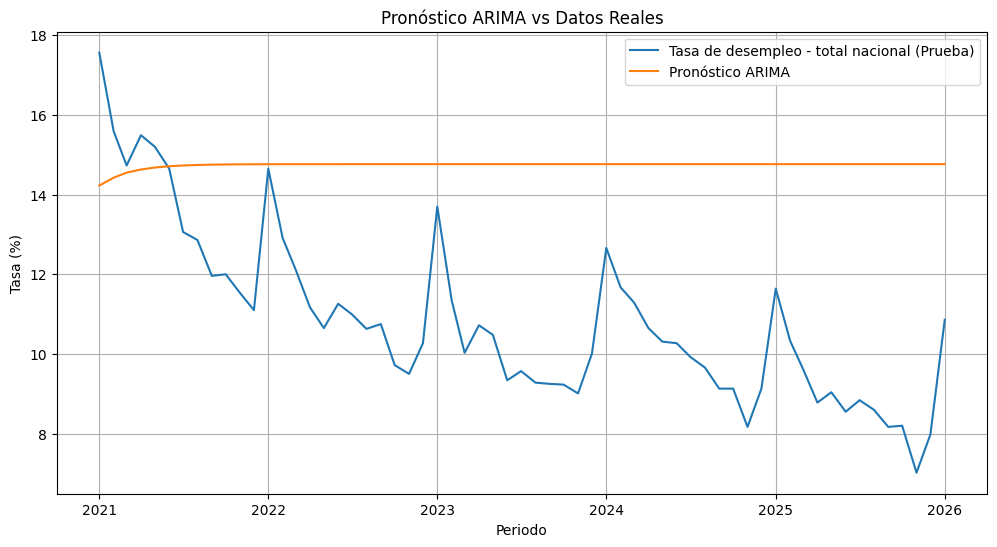

In [17]:
# ya tenemos entrenado el modelo ARIMA como nuestro modelo final
# ahora podemos usarlo para realizar pronósticos futuros
# quiero ver en una grafica los pronósticos del modelo ARIMA junto con los datos reales de prueba
predictions = arima_model_fit.predict(start=test_data.index[0], end=test_data.index[-1])
plt.figure(figsize=(12, 6))
plt.plot(test_data['Periodo(MMM, AAAA)'], test_data['Tasa de desempleo - total nacional'], label='Tasa de desempleo - total nacional (Prueba)')
plt.plot(test_data['Periodo(MMM, AAAA)'], predictions, label='Pronóstico ARIMA')
plt.xlabel('Periodo')
plt.ylabel('Tasa (%)')
plt.title('Pronóstico ARIMA vs Datos Reales')
plt.legend()
plt.grid()
plt.show()

In [18]:
# vamos a entrenarlo mejor con un SARIMA con mejores hiperparámetros
sarima_model = SARIMAX(train_data['Tasa de desempleo - total nacional'], order=(2,1,2), seasonal_order=(1,1,1,12))
sarima_model_fit = sarima_model.fit()
sarima_mse, sarima_mae = evaluate_model(sarima_model_fit, test_data, 'Tasa de desempleo - total nacional')
print(f'SARIMA Mejorado - MSE: {sarima_mse}, MAE: {sarima_mae}')  

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


SARIMA Mejorado - MSE: 55.305377789840236, MAE: 6.819096762615951


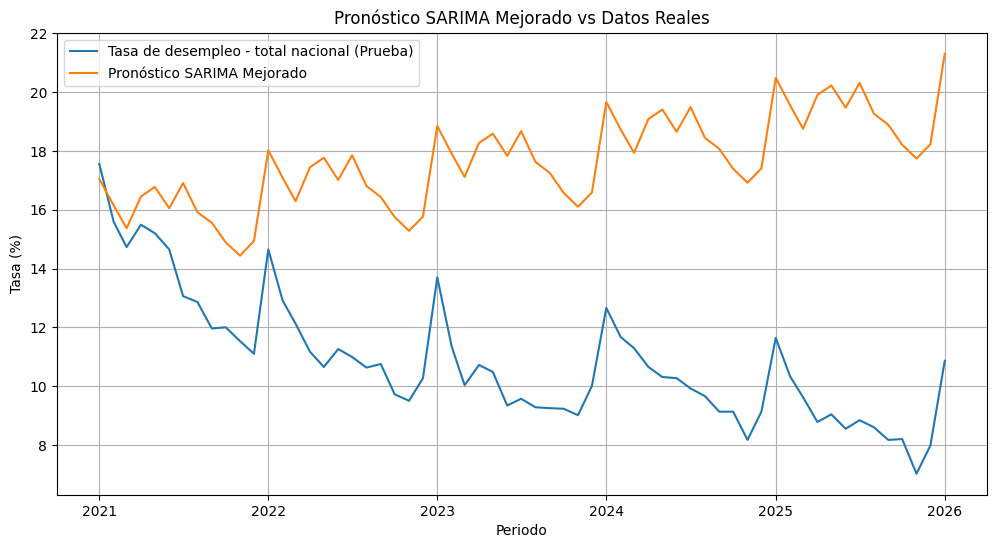

In [19]:
# ahora si graficamos el pronóstico del modelo SARIMA mejorado junto con los datos reales de prueba
predictions_sarima = sarima_model_fit.predict(start=test_data.index[0], end=test_data.index[-1])
plt.figure(figsize=(12, 6))
plt.plot(test_data['Periodo(MMM, AAAA)'], test_data['Tasa de desempleo - total nacional'], label='Tasa de desempleo - total nacional (Prueba)')
plt.plot(test_data['Periodo(MMM, AAAA)'], predictions_sarima, label='Pronóstico SARIMA Mejorado')
plt.xlabel('Periodo')
plt.ylabel('Tasa (%)')
plt.title('Pronóstico SARIMA Mejorado vs Datos Reales')
plt.legend()
plt.grid()
plt.show()

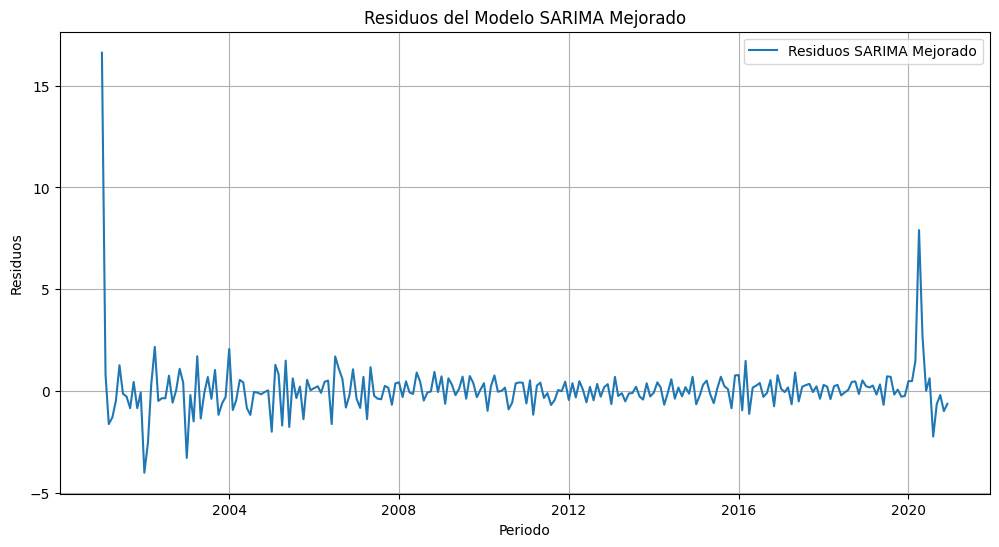

In [23]:
# vamos a ver los residuos del modelo SARIMA mejorado en el periodo de entrenamiento
residuals = sarima_model_fit.resid
plt.figure(figsize=(12, 6))
plt.plot(train_data['Periodo(MMM, AAAA)'], residuals, label='Residuos SARIMA Mejorado')
plt.xlabel('Periodo')
plt.ylabel('Residuos')
plt.title('Residuos del Modelo SARIMA Mejorado')
plt.legend()
plt.grid()
plt.show()